# Маркетинговый анализ с использованием метода bootstrap ("бутстрап")

<span style='font-size: 14pt'>Для этого задaния я буду использовать базу данных сети продуктовых магазинов, скачанную с популярной data science платформы kaggle</span>  
  
Этот датасет содержит информацию о 2240 клиентах сети розничных продуктовых магазинов и о шести рекламных кампаниях, причём первые пять рекламных акций - подготовительные, а последняя - целевая.  
   
<span style='font-size: 14pt'>Поля, которые содержит таблица:</span>
<style>
.blue-bg { background-color: #AEEDF5; }
</style>
1. Реакция клиентов на рекламные акции
- AcceptedCmp1 — принял ли клиент предложение в <span class='blue-bg'>первой</span> кампании, 0 или 1
- AcceptedCmp2 — принял ли клиент предложение во <span class='blue-bg'>второй</span> кампании, 0 или 1
- AcceptedCmp3 — принял ли клиент предложение в <span class='blue-bg'>третьей</span> кампании, 0 или 1
- AcceptedCmp4 — принял ли клиент предложение в <span class='blue-bg'>четвёртой</span> кампании, 0 или 1
- AcceptedCmp5 — принял ли клиент предложение в <span class='blue-bg'>пятой</span> кампании, 0 или 1
- Response — принял ли клиент предложение в <span class='blue-bg'>последней (целевой)</span> кампании, 0 или 1

2. Информация о клиентах
- Year_Birth - дата рождения
- Dt_Customer - дата, когда клиент стал "известным" для компании, например получил карту лояльности или зарегестрировался на сайте
- Education — уровень образования клиента
- Marital_Status — семейное положение клиента
- Kidhome — количество маленьких детей в семье клиента
- Teenhome — количество подростков в семье клиента
- Income — годовой доход домохозяйства клиента
- Z_CostContact - сколько стоит один контакт с клиентом
- Z_Revenue - выручка с клиента после его отклика хотя бы на одну из рекламных акций

3. Информация о тратах клиента на определённые виды продуктов
- MntFishProducts — сумма, потраченная на <span class='blue-bg'>рыбную продукцию</span> за последние 2 года
- MntMeatProducts — сумма, потраченная на <span class='blue-bg'>мясную продукцию</span> за последние 2 года
- MntFruits — сумма, потраченная на <span class='blue-bg'>фруктовую продукцию</span> за последние 2 года
- MntSweetProducts — сумма, потраченная на <span class='blue-bg'>сладкие продукты</span> за последние 2 года
- MntWines — сумма, потраченная на <span class='blue-bg'>винную продукцию</span> за последние 2 года
- MntGoldProds — сумма, потраченная на <span class='blue-bg'>золотые изделия</span> за последние 2 года

4. Поведение клиента
- Complain — 1, если клиент жаловался в течение последних 2 лет
- NumDealsPurchases — количество покупок, совершённых <span class='blue-bg'>со скидкой</span>
- NumCatalogPurchases — количество покупок, совершённых <span class='blue-bg'>по каталогу</span>
- NumStorePurchases — количество покупок, совершённых <span class='blue-bg'>непосредственно в магазинах</span>
- NumWebPurchases — количество покупок, совершённых <span class='blue-bg'>через веб-сайт компании</span>
- NumWebVisitsMonth — количество посещений веб-сайта компании за последний месяц
- Recency — количество дней с момента последней покупки

*Стоит отметить, что этот набор данных больше похож на учебный. Сложно представить, что у сети продуктовых магазинов окажутся данные об образовании, доходе семьи, количестве детей и других личных характеристиках клиента*

In [7]:
# импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import kstest, norm
from scipy.stats import chi2_contingency, fisher_exact

In [3]:
# импортируем данные
data = pd.read_csv('/Users/alferova_tv/Documents/Statistics/marketing/archive/marketing_campaign.csv', sep=';')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [ ]:
# посмотрим типы, пропуски и количество уникальных значений
info_df = pd.DataFrame({
    "Column": data.columns,
    "DType": data.dtypes.astype(str),
    "Missing": data.isna().sum(),
    "Unique": data.nunique()
})
info_df.reset_index(drop=True)

,Column,DType,Missing,Unique
0,ID,int64,0,2240
1,Year_Birth,int64,0,59
2,Education,object,0,5
3,Marital_Status,object,0,8
4,Income,float64,24,1974
5,Kidhome,int64,0,3
6,Teenhome,int64,0,3
7,Dt_Customer,object,0,663
8,Recency,int64,0,100
9,MntWines,int64,0,776


## I. Полупараметрический bootstrap

Используем его в регрессионном анализе. Проверим, есть ли зависимость между количеством детей в семье клиента и суммой, потраченной им на сладкие продукты за последние 2 года.  
Интуитивно хочется предположить, что такая зависимость есть: больше детей - больше сладостей (линейная регрессия)

То есть, предполагаем, что существует такая функция y = 𝛽₀ + 𝛽₁x₁ + ⋯ + 𝛽ᵣxᵣ + 𝜀, где y - сумма трат на сладкое, x - количество детей в семье, 𝛽 - коэффициенты, 𝜀 - погрешность

In [3]:
data['num_children'] = data['Kidhome'] + data['Teenhome'] # новый столбец - общее количество детей

# создаём массивы из наших полей
x = np.array(data['num_children']).reshape(-1, 1) # независимая переменная
y = np.array(data['MntSweetProducts']) # зависимая переменная

model = LinearRegression().fit(x, y) # модель линейной регрессии
beta0 = model.intercept_
beta1 = model.coef_[0]

# посмотрим коэффициенты модели
print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])

y_pred = model.predict(x)

Intercept (β0): 47.05801280479697
Slope (β1): -21.037552222989763


Итерпретация:
Результат получился неожиданный: количество детей, вопреки интуитивным догадкам, уменьшает траты клиента на сладкое.  
Или буквально: траты на сладкое = 47.06  –  21.04 * число_детей
- средние траты на сладости у клиента без детей - примерно 47
- каждый дополнительный ребёнок уменьшает траты на сладости примерно на 21

Такой результат может говорить о том, что семьи с детьми больше экономят и покупают в основном базовые продукты (молоко, хлеб, мясо).
Также возможно, что в данных просто мало детей (это тоже гипотезы, требующие проверки, а не точные удтверждения)

In [ ]:
# смотрим распредлеление клиентов по количесву детей, и средние траты на сладкое в соответствующих группах
print(data.groupby(['num_children'])['ID'].count())
print()
print(data.groupby('num_children')['MntSweetProducts'].mean())

num_children
0     638
1    1128
2     421
3      53
Name: ID, dtype: int64

num_children
0    53.061129
1    20.295213
2     8.370546
3     6.622642
Name: MntSweetProducts, dtype: float64


И правда, с увеличением детей уменьшается средняя сумма трат на сладости. Но детей в данных достаточно - больше половины клиентов имеют 1 ребёнка

In [5]:
# посмотрим качество модели
print(model.score(x, y))

0.14679404935587625


Количество детей объясняет примерно 14.7% вариации трат на сладкие продукты. Есть слабая зависимость, но для маркетинговых данных, где поведение клиента зависит от множества факторов, этот результат довольно значимый.  
Вывод: есть зависимость, но она слабая

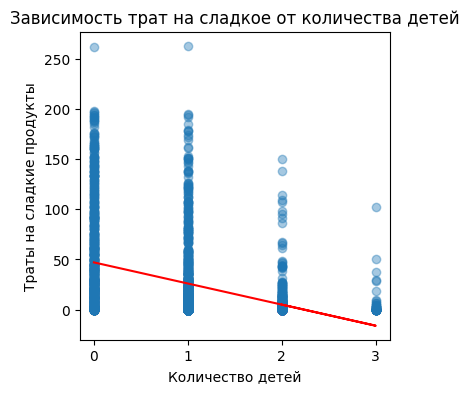

In [6]:
# построим диаграмму рассеяния с линией регрессии
plt.figure(figsize=(4,4))

plt.scatter(x, y, alpha=0.4)

plt.plot(x, y_pred, color='red')

plt.xticks([0, 1, 2, 3])
plt.xlabel('Количество детей')
plt.ylabel('Траты на сладкие продукты')
plt.title('Зависимость трат на сладкое от количества детей') 

plt.show()

Теперь усилим характеристики регрессии с помощью полупараметрического бутстрапа.  
Для данного случая он подходиит больше других, так как x представляет собой несколько категорий (0, 1, 2, 3) и в бутстрап-выборках частоты категорий будут случайными, это будет искажать реальное распределение. 
В полупараметрическом бутстрапе мы будем бутстрапировать не сами выборки, а ошибку 𝜀,

Пошагово:<br>
1. Находим остатки 𝜀<br>
2. Перемешиваем остатки<br>
3. Создаём новые значения y\* = ŷ + ε\*<br>
4. Обучаем регрессию на данных (x, y\*)<br>
5. Сохраняем β₁\*<br>
6. Повторяем 2000<br>

В итоге получаем:<br>
- распределение β₁<br>
- доверительный интервал<br>
- вероятность того, что β₁ < 0<br>

In [7]:
residuals = y - y_pred # остатки модели

B = 2000
boot_betas = []
n = len(y)

for _ in range(B):
    # случайная выборка остатков с повторением
    eps_star = np.random.choice(residuals, size=n, replace=True)
    
    # генерируем новые y*
    y_star = y_pred + eps_star
    
    # обучаем регрессию на новых данных
    model_star = LinearRegression().fit(x, y_star)
    boot_betas.append(model_star.coef_[0])

boot_betas = np.array(boot_betas)

# Доверительный интервал
ci_low = np.percentile(boot_betas, 2.5)
ci_high = np.percentile(boot_betas, 97.5)

print('95% бутстрапный доверительный интервал для β1:', (ci_low, ci_high))
print('P(β1 < 0):', np.mean(boot_betas < 0))

95% бутстрапный доверительный интервал для β1: (np.float64(-23.13377817646093), np.float64(-18.973721018582765))
P(β1 < 0): 1.0


Интервал полностью отрицательный и довольно узкий.  
Ни в одной бутстрап-выборке коэффициент β1 не оказался большим либо равным 0

Посроим график распределения коэффииентов β1

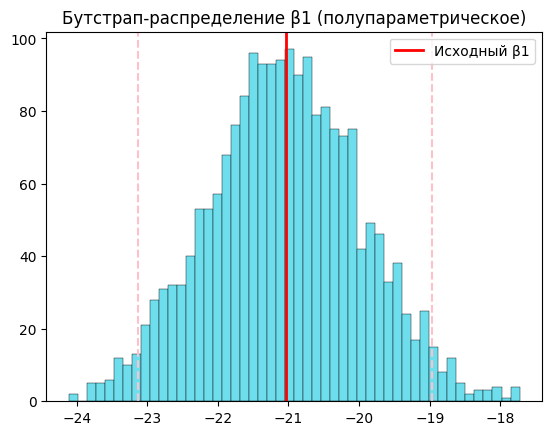

In [8]:
plt.hist(boot_betas, bins=50, edgecolor='black', linewidth=0.3, color='#6EDEED')
plt.axvline(beta1, color='red', linewidth=2, label='Исходный β1')
plt.axvline(ci_low, color='pink', linestyle='--')
plt.axvline(ci_high, color='pink', linestyle='--')
plt.title("Бутстрап-распределение β1 (полупараметрическое)")
plt.legend()
plt.show()

#### Резюме
>В рамках линейной модели и имеющегося набора данных увеличение количества детей статистически значимо связано со снижением трат на сладкие продукты. Однако это не доказывает причинно-следственную связь и может быть результатом других факторов

## II. Непараметрический бутстрап

Теперь проверим похожую гипотезу с тратами на вино. Проверим, есть ли связь между семейным положением и суммой, потраченной на винную продукцию за последние 2 года.  
Опять же, интуитивно хочется предположить, что одинокие люди чаще покупают алкоголь, чем семейные

<p>Итак,  проверим следующие гипотезы:</p>

**H₀: Семейное положение не влияет на траты на винную продукцию**</br>

**H₁: Семейное положение влияет на траты на винную продукцию**

Для этого буду использовать дисперсионный анализ или ANOVA, алгоритм взяла из книги Сары Бослаф "Статистика для всех" 

Зависимая переменная y - сумма, потраченная на винную продукцию (непрерывная)</br>
Независимая переменная x - семейное положение (категориальная)</br>
Значения y не зависят друг от друга</br>
</br>
\- это подходит для ANOVA

Ещё одно условие - приблизительно нормальное распределение y в каждой группе. 
Для начала посмотрим размеры групп

In [3]:
data.groupby(['Marital_Status'])['ID'].count()

Marital_Status
Absurd        2
Alone         3
Divorced    232
Married     864
Single      480
Together    580
Widow        77
YOLO          2
Name: ID, dtype: int64

Группы со статусами "Absurd", "Alone", "YOLO" слишком маленькие, их проверять бессмысленно. У группы "Widow" размер 77, а у остальных даже больше 200. Поэтому можно проверить их распределения на нормальность с помощью критерия Колмогорова-Смирнова

In [5]:
# Проверим с помощью критерия Колмогорова-Смирнова
for status in data['Marital_Status'].unique(): 
    subset = data[data['Marital_Status'] == status]['MntWines']
    
    # слишком маленькие группы пропустим
    if len(subset) < 10:
        print(status, "— мало данных (n < 10)")
        continue
    
    mu, sigma = subset.mean(), subset.std(ddof=1)

    if sigma == 0:
        print(status, "— все значения одинаковы, тест не применим")
        continue

    stat, p = kstest(subset, 'norm', args=(mu, sigma))
    print(f'{status}, {p >= 0.05}, p = {p}')

Single, False, p = 3.3976891725662063e-16
Together, False, p = 7.873001456029385e-17
Married, False, p = 3.78115980025644e-27
Divorced, False, p = 1.1638620433949211e-06
Widow, True, p = 0.10980979545429914
Alone — мало данных (n < 10)
Absurd — мало данных (n < 10)
YOLO — мало данных (n < 10)


Получилось, что только у группы со стаусом вдова/вдовец траты на винную продукцию распределены приблизительно нормально. У четырёх первых групп p-значения намного меньше границы, также размеры групп не одинаковые. Скорее всего распределение трат на винную продукцию сильно скошено, в таком случае ANOVA не будет достоверным. 

Посмотрим коэффициент ассиметрии трат на винную продукцию

In [36]:
from scipy.stats import skew
x = data["MntWines"].dropna()
print("Skewness:", skew(x))

Skewness: 1.1749830708938132


И правда, есть длинный хвост справа: много людей покупают мало вина, но есть небольшая группа людей, которые покупают много вина

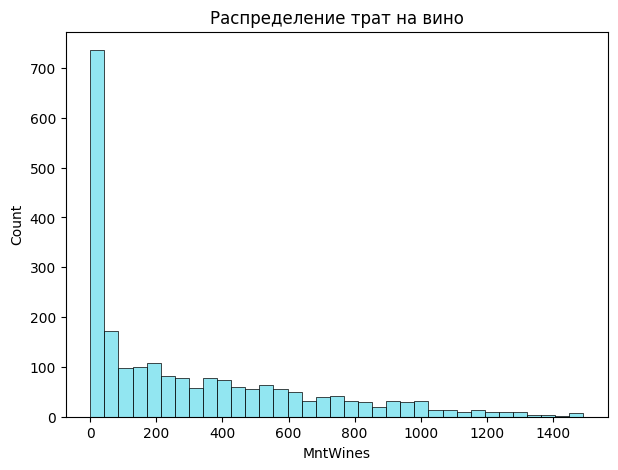

In [45]:
# построим гистограмму распределения
plt.figure(figsize=(7,5))
sns.histplot(data['MntWines'], kde=False, bins=35, linewidth=0.5, edgecolor='black', color='#6EDEED')
plt.xlabel('MntWines')
plt.ylabel('Count')
plt.title('Распределение трат на вино')
plt.show()

В этом случае как раз поможет непараметрический бутстрап. Используем его, чтобы проверить

**H₀: ​μ (мат. ожидание) по всем группам одинаковые** </br>
  
**H₁: Хотя бы одна группа отличается по мат. ожиданию**


Бутстрап позволит оценить распределение F-статистики (или разности средних) без предположения о нормальности.  
Идея в том, чтобы оставить траты такими как есть, но случайным образам подставлять к ним названия групп много раз. То есть смоделировать такую ситуацию, в которой нулевая гипотеза истинна.   
После перестановок посчитаем F-статистику, она покажет, какими могут быть различия случайно, без разделения по группам.  
*Если группы реально не влияют, то их названия можно менять местами — ничего не изменится. Если же эффект есть, то реальная F-статистика окажется намного больше, чем F-статистики из перестановочных выборок.*   

Отсюда определим p-значение P(Fслучайная ​≥ Fреальная​)

In [5]:
df = data[['Marital_Status', 'MntWines']].copy() 
df = df[df['Marital_Status'].isin(['Single','Together','Married','Divorced','Widow'])] # исключаем слишком маленькие группы, чтобы не искажать тест

groups = [df[df['Marital_Status'] == status]['MntWines'].values for status in df['Marital_Status'].unique()] # массив со списками трат для каждой группы

from scipy.stats import f_oneway
F_real = f_oneway(*groups)[0] # однофакторный ANOVA на реальных данных (реальная F-статистика)

# 2. Перестановочный бутстрап
B = 5000
F_boot = []

for _ in range(B):
    shuffled = np.random.permutation(df['Marital_Status']) # перемешиваем метки групп
    df['shuffled_group'] = shuffled # добавляем в датафрейм перемешанные группы
    
    groups_shuffled = [df[df['shuffled_group'] == status]['MntWines'].values for status in df['Marital_Status'].unique()] # массив со списками трат для каждой группы после перемешивания
    
    F = f_oneway(*groups_shuffled)[0] # считаем F-статистику для перемешанных данных
    F_boot.append(F) # сохраняем значение F-статистики

F_boot = np.array(F_boot)

# 3. p-value
p_value = np.mean(F_boot >= F_real) # доля случаев, когда F-статистика из бутстрапа больше или равна реальной

print("Real F-statistic:", F_real)
print("Bootstrap p-value:", p_value)

Real F-statistic: 1.25343747865223
Bootstrap p-value: 0.2826


Итак, наше p-значение получилось намного больше 0,05, а значит, нет оснований отвергать нулевую гипотезу о том, что различий между группами нет.  
Буквально ~28% случайных перестановок дали F-статистику не меньше, чем реальная, значит различия между группами легко возникают из-за простой случайности.  
F-статистика в данном случае - это отношение дисперсий между группами и внутри групп, значение 1,25 говорит о том, что группы отличаются не сильно 

#### Резюме
>Статистически значимых различий трат на вино между клиентами разных семейных положений нет. Семейное положение НЕ оказывает заметного влияния на траты на вино у клиентов в этом наборе данных

### Влияние первых 5 рекламных акций на эффективность шестой.

Проверим логичный и сам собой возникающий вопрос относительно этих данных:   
Связаны ли отклики на 5 подготовительных кампаний с вероятностью отклика на целевую кампанию? И насколько этот сигнал устойчив. 

Сразу стоит сказать, что корреляция не равна причинности.
Если клиент откликается на все кампании, это может быть просто «активный клиент», показатель лояльности аудитории, или же людей действительно «раскачали» и подготовили.  
Мы можем проверить только связь, а не причину и следствие.

Для начала по каждой из 5 кампаний проверим бинарную корреляцию с целевой кампанией, рассмотрим следующие гипотезы:   
H0​: P(target = 1 ∣ pre_i = 1) = P( target=1 ∣ pre_i = 0) <span style='font-style: italic; color: grey;'>Вероятности отклика на целевую акцию при наличии отклика на акцию под номером i и при его отсуьствии равны </span>  
H1​: P(target = 1 ∣ pre_i = 1) > P( target=1 ∣ pre_i = 0) <span style='font-style: italic; color: grey;'>Вероятность отклика на целевую акцию при наличии отклика на акцию под номером i больше, чем при его отсутствии</span>  

In [4]:
campaigns = data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']] # отдельная таблица по откликам
campaigns

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,0,0,0,0,0,1
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2235,0,0,0,0,0,0
2236,1,0,0,0,0,0
2237,0,0,0,1,0,0
2238,0,0,0,0,0,0


In [5]:
# построим таблицу: вероятность отклика на целевую кампанию если был отклик на кампанию i | не было отклика на кампанию i | разница
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
results = []

for col in campaign_cols:
    p_response_if_1 = campaigns.loc[campaigns[col] == 1, 'Response'].mean()
    p_response_if_0 = campaigns.loc[campaigns[col] == 0, 'Response'].mean()

    results.append({
        'Campaign': col,
        'P(Response=1 | Accepted=1)': p_response_if_1,
        'P(Response=1 | Accepted=0)': p_response_if_0,
        'Difference (Δ)': p_response_if_1 - p_response_if_0
    })

prob_table = pd.DataFrame(results)
prob_table

,Campaign,P(Response=1 | Accepted=1),P(Response=1 | Accepted=0),Difference (Δ)
0,AcceptedCmp1,0.548611,0.121660,0.426951
1,AcceptedCmp2,0.666667,0.142081,0.524585
2,AcceptedCmp3,0.472393,0.123736,0.348656
3,AcceptedCmp4,0.371257,0.131211,0.240047
4,AcceptedCmp5,0.564417,0.116514,0.447903


Это оптимистичный и внушительный результат. Люди, которые откликались на предварительные акции в 3-6 раз чаще откликаются на целевую.

In [6]:
# Для каждой кампании построим таблицу 2x2
for col in campaign_cols:
    contingency_table = pd.crosstab(campaigns[col], campaigns['Response'])
    print(f'Cross-table for {col}:\n', contingency_table, '\n')

Cross-table for AcceptedCmp1:
 Response         0    1
AcceptedCmp1           
0             1841  255
1               65   79 

Cross-table for AcceptedCmp2:
 Response         0    1
AcceptedCmp2           
0             1896  314
1               10   20 

Cross-table for AcceptedCmp3:
 Response         0    1
AcceptedCmp3           
0             1820  257
1               86   77 

Cross-table for AcceptedCmp4:
 Response         0    1
AcceptedCmp4           
0             1801  272
1              105   62 

Cross-table for AcceptedCmp5:
 Response         0    1
AcceptedCmp5           
0             1835  242
1               71   92 



Теперь можно проверить зависимость этих частоты с помощью хи-квадрат теста независимости. Но для второй кампании сделаем исключение и используем точный тест Фишера (Fisher's exact test), потому что частоты довольно малы: во второй строке всего 30 наблюдений, а в одной из ячеек - 10.   
Желаемый результат - получить p-value < 0,05. Это подтвердит зависимость отклика на подготовительную кампанию и отклика на целевую

In [10]:
results = []

for col in campaign_cols:
    
    ct = pd.crosstab(campaigns[col], campaigns['Response'])
    
    if col == 'AcceptedCmp2':  # Fisher для кампании 2
        odds_ratio, p = fisher_exact(ct)
        results.append({
            'Campaign': col,
            'Test': 'Fisher',
            'Statistic': odds_ratio,
            'p-value': p
        })
    else:
        chi2, p_value, dof, expected = chi2_contingency(ct) # хи-квадрат, p-value, число степеней свободы, ожидаемые частоты
        results.append({
            'Campaign': col,
            'Test': 'Chi-square',
            'Statistic': chi2,
            'p-value': p_value
        })

results_df = pd.DataFrame(results)
results_df

,Campaign,Test,Statistic,p-value
0,AcceptedCmp1,Chi-square,190.241783,2.815498e-43
1,AcceptedCmp2,Fisher,12.076433,1.270973e-10
2,AcceptedCmp3,Chi-square,142.074884,9.364996e-33
3,AcceptedCmp4,Chi-square,68.312456,1.395368e-16
4,AcceptedCmp5,Chi-square,235.467749,3.828045e-53


P-value у всех кампаний получилось очень маленьким, значит независимость отвергается.  
Проверим силу этих связей с помощью критерия Крамера. Связь может быть статистически значимой, но при этом очень маленькой

In [15]:
# Считаем критерий Крамера V для каждой кампании по табличкам 2x2
for col in campaign_cols:
    contingency_table = pd.crosstab(campaigns[col], campaigns['Response'])
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    V = np.sqrt(chi2 / n)

    #Для критерия Крамера 0.1 – 0.29: Слабая связь, 0.3 – 0.49: Умеренная (средняя) связь
    category = {} 
    if V < 0.3:
        category[col] = "Слабая связь"
    elif V < 0.5:
        category[col] = "Умеренная (заметная) связь"
    else:
        category[col] = "Сильная связь"

    print(f'Критерий Крамера V для кампании {col}: {V} - {category[col]}')


Критерий Крамера V для кампании AcceptedCmp1: 0.29142643536008733 - Слабая связь
Критерий Крамера V для кампании AcceptedCmp2: 0.16384102862243402 - Слабая связь
Критерий Крамера V для кампании AcceptedCmp3: 0.2518457612035232 - Слабая связь
Критерий Крамера V для кампании AcceptedCmp4: 0.17463284962923903 - Слабая связь
Критерий Крамера V для кампании AcceptedCmp5: 0.3242214225767795 - Умеренная (заметная) связь


>Согласно полученным значениям, для большинства подготовительных кампаний наблюдается слабая связь с откликом на целевую кампанию, в то время как для кампании AcceptedCmp5 связь может быть охарактеризована как умеренная.  
>Интерпретация критерия Крамера V носит рекомендательный характер и зависит от предметной области; в работе использовалась одна из общепринятых шкал

Далее могут возникнуть вопросы: «насколько устойчив этот эффект и не является ли он характеристикой конкретной выборки?»  
Также хочется иметь основания для предсказаний, а не просто найти связь, поэтому применим метод бутстрапа.  
Для данного случая подойдёт бутстрап доверительного интервала  

**Δ = P(Response=1∣AcceptedCmpi​=1) − P(Response=1∣AcceptedCmpi​=0)**  
*Иными словами мы ищем ответ на вопрос: «Если бы мы взяли похожую выборку, насколько бы вариировался эффект?»*

КЛАСТЕРИЗАЦИЯ